  Project_ID  Team_Size  Project_Duration_Months  Budget  Tasks_Completed  \
0       P101          5                        6   50000               45   
1       P102          8                       12  120000               60   
2       P103          4                        4   30000               20   
3       P104         10                       18  250000               90   
4       P105          6                        8   70000               40   

   Client_Satisfaction Risk_Level Project_Status  
0                    8        Low      Completed  
1                    7     Medium      Completed  
2                    6       High        Delayed  
3                    9        Low      Completed  
4                    5     Medium        Delayed  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Project_ID        

/tmp/ipykernel_3028/1879204217.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_3028/1879204217.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Accuracy Score : 0.75


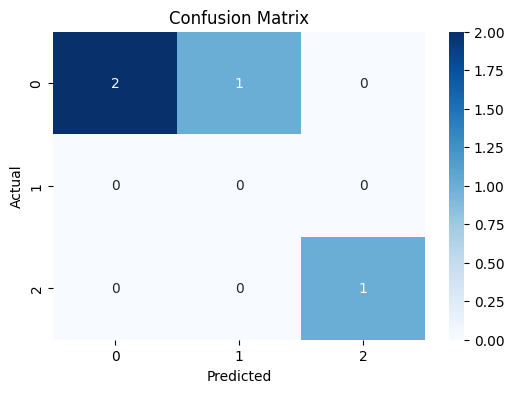

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0
           2       1.00      1.00      1.00         1

    accuracy                           0.75         4
   macro avg       0.67      0.56      0.60         4
weighted avg       1.00      0.75      0.85         4



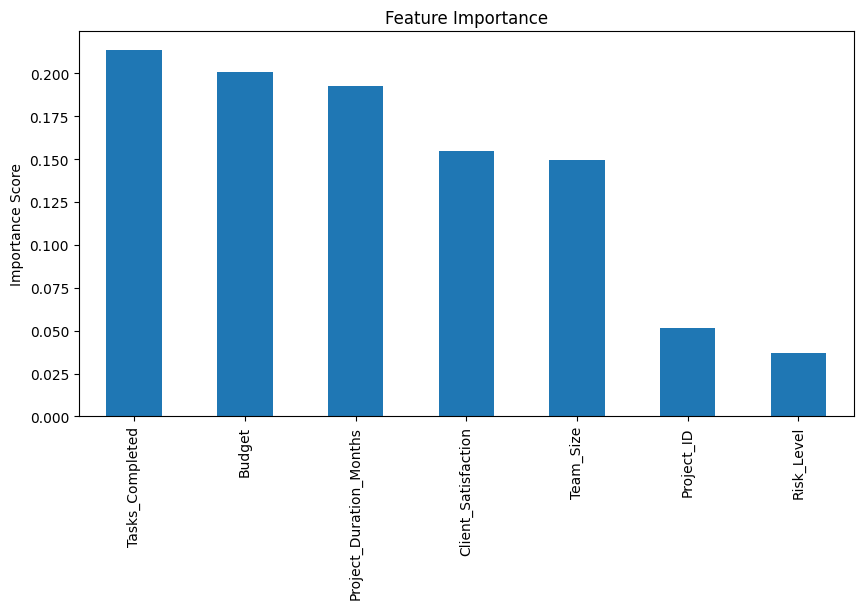

Model Training and Evaluation Completed


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

df = pd.read_csv("/Project_Management_Sample_Data.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

target_column = df.columns[-1]

X = df.drop(target_column, axis=1)

y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, y_pred))

if len(np.unique(y)) == 2:

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))

    plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

print("Model Training and Evaluation Completed")